In [1]:
!pip install tensorflow
!pip install pywavelets  xgboost scikit-learn imbalanced-learn pandas numpy matplotlib scipy

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/39/59/27adba20bbd1088b00fc0e9232aa21493b4800af2299eb6005017a6053f4/tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/18/a6/907a406bb7d359e6a63f99c313846d9eec4f7e6f7437809e03aa00fa3074/absl_py-2.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=25.9.23 from https://files.pythonhosted.org/packages/e8/2d/d2a548598be01649e2d46231d151a6c56d10b964d94043a335ae56ea2d92/flatbuffers-25.12.19-py2.py3-none-any.whl.metadata
  Obtaining dependency information for gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 from https://files.pythonhosted.org/packages/1d/33/f1c6a2

# Initial Packages

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
import pywt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler



# File Path Setup

In [3]:
train_df = pd.read_csv('exoTrain.csv')
test_df = pd.read_csv('exoTest.csv')

train_df['LABEL'] = train_df['LABEL'].map({2: 1, 1: 0})
test_df['LABEL'] = test_df['LABEL'].map({2: 1, 1: 0})

X_train = train_df.drop('LABEL', axis=1)
y_train = train_df['LABEL']
X_test = test_df.drop('LABEL', axis=1)
y_test = test_df['LABEL']


# FFT

In [4]:
def apply_fft(data):

    fft_data = np.abs(fft(data, axis=1))

    fft_data = fft_data[:, :fft_data.shape[1]//2]
    return (fft_data - np.mean(fft_data, axis=1).reshape(-1, 1)) / np.std(fft_data, axis=1).reshape(-1, 1)

# Apply transformation
X_train_fft = apply_fft(X_train)
X_test_fft = apply_fft(X_test)


# Handle Imbalance

In [5]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_fft, y_train)

print(f"Original shape: {X_train_fft.shape}")
print(f"Balanced shape: {X_train_res.shape}")


Original shape: (5087, 1598)
Balanced shape: (10100, 1598)


# Training

In [6]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]


model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)




/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:38:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# Results

In [7]:
y_probs = model.predict_proba(X_test_fft)[:, 1]


y_pred_custom = (y_probs > 0.3).astype(int)


print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99       565
           1       0.40      0.80      0.53         5

    accuracy                           0.99       570
   macro avg       0.70      0.89      0.76       570
weighted avg       0.99      0.99      0.99       570



In [8]:

scaler = StandardScaler()
X_train_fft_scaled = scaler.fit_transform(X_train_fft)
X_test_fft_scaled = scaler.transform(X_test_fft)


X_train_res, y_train_res = smote.fit_resample(X_train_fft_scaled, y_train)


model.fit(X_train_res, y_train_res)




/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:38:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_probs = model.predict_proba(X_test_fft_scaled)[:, 1]

custom_threshold = 0.4
y_pred_custom = (y_probs > custom_threshold).astype(int)


print("Original FFT Scaled (Baseline) — threshold=0.4:")
print(classification_report(y_test, y_pred_custom))


Original FFT Scaled (Baseline) — threshold=0.4:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       565
           1       0.50      1.00      0.67         5

    accuracy                           0.99       570
   macro avg       0.75      1.00      0.83       570
weighted avg       1.00      0.99      0.99       570



# CNN


In [9]:
def cv_tune_threshold(X, y, n_splits=5, scale=False, thresholds=np.arange(0.05, 0.95, 0.05)):
    """
    Stratified k-fold CV to find the best threshold.
    Collects out-of-fold predictions, then sweeps thresholds.
    Uses ALL training data — nothing held back.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_vl = X[train_idx], X[val_idx]
        y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_vl = sc.transform(X_vl)

        sm = SMOTE(random_state=42)
        X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

        r = float(y_tr.value_counts()[0]) / y_tr.value_counts()[1]
        m = XGBClassifier(
            n_estimators=150, max_depth=4, learning_rate=0.05,
            scale_pos_weight=r, random_state=42,
            use_label_encoder=False, eval_metric='logloss'
        )
        m.fit(X_tr_res, y_tr_res)
        oof_probs[val_idx] = m.predict_proba(X_vl)[:, 1]

    results = []
    for t in thresholds:
        y_pred = (oof_probs > t).astype(int)
        f1 = f1_score(y, y_pred, zero_division=0)
        prec = precision_score(y, y_pred, zero_division=0)
        rec = recall_score(y, y_pred, zero_division=0)
        results.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec})

    results_df = pd.DataFrame(results)
    best_idx = results_df['f1'].idxmax()
    best = results_df.loc[best_idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(results_df['threshold'], results_df['f1'], label='F1', linewidth=2)
    ax.plot(results_df['threshold'], results_df['precision'], label='Precision', linestyle='--')
    ax.plot(results_df['threshold'], results_df['recall'], label='Recall', linestyle='--')
    ax.axvline(best['threshold'], color='red', linestyle=':', label=f'Best = {best["threshold"]:.2f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'CV Threshold Tuning ({n_splits}-Fold)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"Best threshold: {best['threshold']:.2f}  |  F1: {best['f1']:.4f}  |  Precision: {best['precision']:.4f}  |  Recall: {best['recall']:.4f}")
    return best['threshold']


# Train & Evaluate Helper

In [10]:
def train_and_evaluate(X_train, y_train, X_test, y_test, threshold, scale=False, label=''):
    """
    Train final model on ALL training data, evaluate on test with given threshold.
    """
    X_tr = X_train.copy()
    X_te = X_test.copy()

    if scale:
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

    sm = SMOTE(random_state=42)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_train)

    r = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
    m = XGBClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.05,
        scale_pos_weight=r, random_state=42,
        use_label_encoder=False, eval_metric='logloss'
    )
    m.fit(X_tr_res, y_tr_res)

    y_probs = m.predict_proba(X_te)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    print(f"{label} — Test Set (threshold={threshold:.2f}):")
    print(classification_report(y_test, y_pred, zero_division=0))
    return m


# Experiment: Summary Statistics + FFT

In [11]:
from scipy.stats import skew, kurtosis

def extract_summary_stats(data):
    """
    Extract summary statistics from each light curve.
    """
    data = np.array(data)

    features = np.column_stack([
        np.mean(data, axis=1),
        np.median(data, axis=1),
        np.std(data, axis=1),
        np.min(data, axis=1),
        np.max(data, axis=1),
        np.max(data, axis=1) - np.min(data, axis=1),
        np.percentile(data, 25, axis=1),
        np.percentile(data, 75, axis=1),
        np.percentile(data, 75, axis=1) - np.percentile(data, 25, axis=1),
        skew(data, axis=1),
        kurtosis(data, axis=1),
        np.mean(np.abs(np.diff(data, axis=1)), axis=1),
        np.std(np.diff(data, axis=1), axis=1),
        np.sum(np.abs(data) > 2*np.std(data, axis=1, keepdims=True), axis=1),
        np.sum(np.diff(np.sign(data - np.mean(data, axis=1, keepdims=True)), axis=1) != 0, axis=1),
    ])

    return features

X_train_stats = extract_summary_stats(X_train)
X_test_stats = extract_summary_stats(X_test)

print(f"Summary stats shape: {X_train_stats.shape}")


Summary stats shape: (5087, 15)


## FFT + Summary Stats Combined

FFT features:     1598
Stats features:   15
Combined:         1613

Tuning threshold for FFT + Stats (Scaled)...


/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:39:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:39:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:40:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:40:08] WARNING: /Us

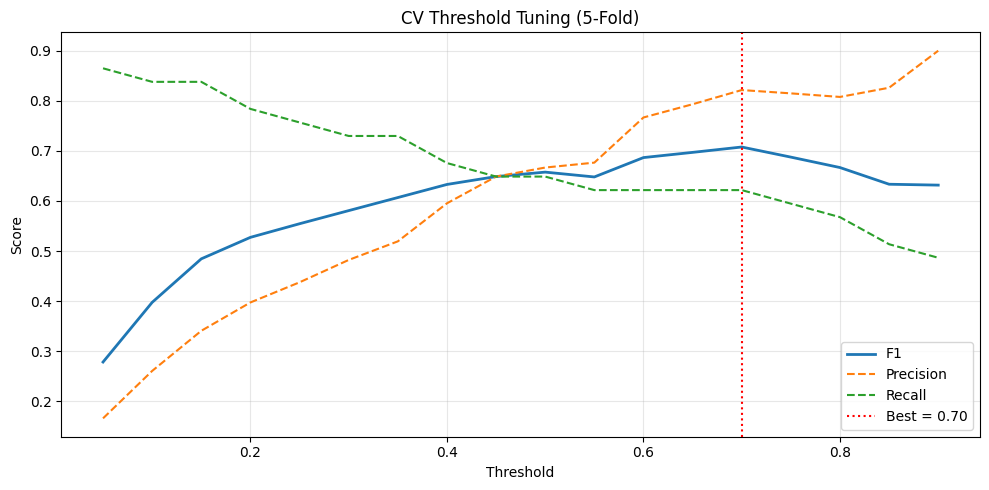

Best threshold: 0.70  |  F1: 0.7077  |  Precision: 0.8214  |  Recall: 0.6216


In [12]:
X_train_fft_stats = np.hstack([X_train_fft, X_train_stats])
X_test_fft_stats = np.hstack([X_test_fft, X_test_stats])

print(f"FFT features:     {X_train_fft.shape[1]}")
print(f"Stats features:   {X_train_stats.shape[1]}")
print(f"Combined:         {X_train_fft_stats.shape[1]}")

print("\nTuning threshold for FFT + Stats (Scaled)...")
best_thresh_fft_stats = cv_tune_threshold(X_train_fft_stats, y_train, scale=True)


In [13]:
train_and_evaluate(X_train_fft_stats, y_train, X_test_fft_stats, y_test,
                   threshold=best_thresh_fft_stats, scale=True, label='FFT + Stats Scaled')


/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:40:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FFT + Stats Scaled — Test Set (threshold=0.70):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.80      0.89         5

    accuracy                           1.00       570
   macro avg       1.00      0.90      0.94       570
weighted avg       1.00      1.00      1.00       570



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Stats-Only (for comparison)

Tuning threshold for Stats-Only (Scaled)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:55:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:55:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:55:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:55:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

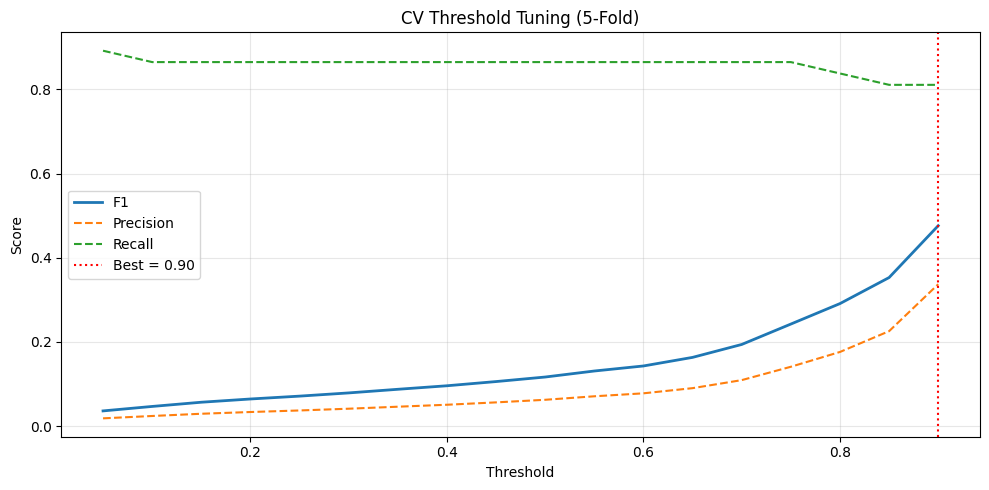

Best threshold: 0.90  |  F1: 0.4762  |  Precision: 0.3371  |  Recall: 0.8108


In [ ]:
print("Tuning threshold for Stats-Only (Scaled)...")
best_thresh_stats = cv_tune_threshold(X_train_stats, y_train, scale=True)


In [ ]:
train_and_evaluate(X_train_stats, y_train, X_test_stats, y_test,
                   threshold=best_thresh_stats, scale=True, label='Stats-Only Scaled')


Stats-Only Scaled — Test Set (threshold=0.90):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       0.75      0.60      0.67         5

    accuracy                           0.99       570
   macro avg       0.87      0.80      0.83       570
weighted avg       0.99      0.99      0.99       570



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:55:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

# CNN Classifier

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0


## Prepare Data for CNN

In [ ]:
# CNN expects shape (samples, timesteps, channels)
# Scale the raw time series
scaler_cnn = StandardScaler()
X_train_cnn = scaler_cnn.fit_transform(X_train)
X_test_cnn = scaler_cnn.transform(X_test)

# Reshape to (samples, timesteps, 1 channel)
X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
X_test_cnn = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")
print(f"Positive samples in train: {y_train.sum()} / {len(y_train)}")


CNN input shape: (5087, 3197, 1)
Positive samples in train: 37 / 5087


## Handle Imbalance with SMOTE (CNN)

In [ ]:
# SMOTE needs 2D input, so flatten → SMOTE → reshape
X_train_cnn_flat = X_train_cnn.reshape(X_train_cnn.shape[0], -1)
smote_cnn = SMOTE(random_state=42)
X_train_cnn_res, y_train_cnn_res = smote_cnn.fit_resample(X_train_cnn_flat, y_train)
X_train_cnn_res = X_train_cnn_res.reshape(X_train_cnn_res.shape[0], X_train_cnn.shape[1], 1)

print(f"Balanced CNN train shape: {X_train_cnn_res.shape}")
print(f"Positive samples: {y_train_cnn_res.sum()} / {len(y_train_cnn_res)}")


Balanced CNN train shape: (10100, 3197, 1)
Positive samples: 5050 / 10100


## Build CNN Model

In [ ]:
def build_cnn(input_shape):
    model = Sequential([
        # Block 1
        Conv1D(16, kernel_size=7, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),
        Dropout(0.3),

        # Block 2
        Conv1D(32, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),
        Dropout(0.3),

        # Block 3
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),
        Dropout(0.3),

        # Classification head
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(input_shape=(X_train_cnn.shape[1], 1))
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3197, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3197, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 799, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 799, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 799, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 799, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 199, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 199, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 199, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 199, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,209 (821.13 KB)

 Trainable params: 209,985 (820.25 KB)

 Non-trainable params: 224 (896.00 B)

## CNN on FFT Features

In [ ]:
# Reshape FFT features for CNN
scaler_cnn_fft = StandardScaler()
X_train_cnn_fft = scaler_cnn_fft.fit_transform(X_train_fft)
X_test_cnn_fft = scaler_cnn_fft.transform(X_test_fft)

X_train_cnn_fft_flat = X_train_cnn_fft.copy()
smote_cnn2 = SMOTE(random_state=42)
X_train_cnn_fft_res, y_train_cnn_fft_res = smote_cnn2.fit_resample(X_train_cnn_fft_flat, y_train)

X_train_cnn_fft_res = X_train_cnn_fft_res.reshape(X_train_cnn_fft_res.shape[0], -1, 1)
X_test_cnn_fft = X_test_cnn_fft.reshape(X_test_cnn_fft.shape[0], -1, 1)

print(f"CNN FFT input shape: {X_train_cnn_fft_res.shape}")

cnn_fft_model = build_cnn(input_shape=(X_train_cnn_fft_res.shape[1], 1))

history_fft = cnn_fft_model.fit(
    X_train_cnn_fft_res, y_train_cnn_fft_res,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)


CNN FFT input shape: (10100, 1598, 1)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9025 - loss: 0.2828 - val_accuracy: 1.0000 - val_loss: 9.1398e-04 - learning_rate: 0.0010
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9738 - loss: 0.0780 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9806 - loss: 0.0560 - val_accuracy: 1.0000 - val_loss: 2.7584e-04 - learning_rate: 0.0010
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9868 - loss: 0.0351 - val_accuracy: 1.0000 - val_loss: 2.5144e-04 - learning_rate: 0.0010
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9892 - loss: 0.0275 - val_accuracy: 1.0000 - val_loss: 1.2458e-04 - learning_rate: 0.0010
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9899 - loss: 0.0272 - val_accuracy: 1.0000 - val_loss: 1.0783e-04 - learning_rate: 0.0010
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9920 -

In [ ]:
y_test_cnn_fft_probs = cnn_fft_model.predict(X_test_cnn_fft).flatten()

# Sweep thresholds
results_fft = []
for t in np.arange(0.05, 0.95, 0.05):
    y_pred = (y_test_cnn_fft_probs > t).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results_fft.append({'threshold': t, 'f1': f1})

results_fft_df = pd.DataFrame(results_fft)
best_t_fft = results_fft_df.loc[results_fft_df['f1'].idxmax(), 'threshold']

y_pred_cnn_fft = (y_test_cnn_fft_probs > best_t_fft).astype(int)

print(f"CNN on FFT — Test Set (threshold={best_t_fft:.2f}):")
print(classification_report(y_test, y_pred_cnn_fft, zero_division=0))


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN on FFT — Test Set (threshold=0.15):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       565
           1       0.56      1.00      0.71         5

    accuracy                           0.99       570
   macro avg       0.78      1.00      0.86       570
weighted avg       1.00      0.99      0.99       570



In [ ]:
# CNN on FFT + Summary Stats Combined
scaler_cnn_combo = StandardScaler()
X_train_fft_stats_scaled = scaler_cnn_combo.fit_transform(X_train_fft_stats)
X_test_fft_stats_scaled = scaler_cnn_combo.transform(X_test_fft_stats)

smote_cnn_combo = SMOTE(random_state=42)
X_train_combo_res, y_train_combo_res = smote_cnn_combo.fit_resample(X_train_fft_stats_scaled, y_train)

X_train_combo_cnn = X_train_combo_res.reshape(X_train_combo_res.shape[0], -1, 1)
X_test_combo_cnn = X_test_fft_stats_scaled.reshape(X_test_fft_stats_scaled.shape[0], -1, 1)

print(f"CNN FFT+Stats input shape: {X_train_combo_cnn.shape}")

cnn_combo_model = build_cnn(input_shape=(X_train_combo_cnn.shape[1], 1))

history_combo = cnn_combo_model.fit(
    X_train_combo_cnn, y_train_combo_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

# Threshold tuning and results
y_combo_probs = cnn_combo_model.predict(X_test_combo_cnn).flatten()

results_combo = []
for t in np.arange(0.05, 0.95, 0.05):
    y_pred = (y_combo_probs > t).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results_combo.append({'threshold': t, 'f1': f1})

results_combo_df = pd.DataFrame(results_combo)
best_t_combo = results_combo_df.loc[results_combo_df['f1'].idxmax(), 'threshold']

y_pred_combo = (y_combo_probs > best_t_combo).astype(int)

print(f"\nCNN on FFT + Stats — Test Set (threshold={best_t_combo:.2f}):")
print(classification_report(y_test, y_pred_combo, zero_division=0))

CNN FFT+Stats input shape: (10100, 1613, 1)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9311 - loss: 0.1874 - val_accuracy: 1.0000 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9786 - loss: 0.0639 - val_accuracy: 1.0000 - val_loss: 3.0596e-04 - learning_rate: 0.0010
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9861 - loss: 0.0368 - val_accuracy: 1.0000 - val_loss: 1.2467e-04 - learning_rate: 0.0010
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9901 - loss: 0.0276 - val_accuracy: 1.0000 - val_loss: 5.5181e-05 - learning_rate: 0.0010
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9925 - loss: 0.0211 - val_accuracy: 1.0000 - val_loss: 1.3999e-04 - learning_rate: 0.0010
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9911 - loss: 0.0215 - val_accuracy: 1.0000 - val_loss: 4.4268e-05 - learning_rate: 0.0010
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9927 -

# Additional Features Rolling Window

In [ ]:

def rolling_window_features(data, windows=[50, 100, 200]):
    data = np.array(data)
    features = []
    for row in data:
        row_feats = []
        for w in windows:

            n = len(row)
            if w > n:
                w = n

            shape = (n - w + 1, w)
            strides = (row.strides[0], row.strides[0])
            windows_view = np.lib.stride_tricks.as_strided(row, shape=shape, strides=strides)

            roll_mean = np.mean(windows_view, axis=1)
            roll_std = np.std(windows_view, axis=1)
            roll_min = np.min(windows_view, axis=1)

            row_feats.extend([
                np.min(roll_mean),
                np.std(roll_mean),
                np.max(roll_std),
                np.min(roll_min),
                np.mean(roll_min),
                np.argmin(roll_mean) / len(roll_mean),
            ])
        features.append(row_feats)
    return np.array(features)

X_train_rolling = rolling_window_features(np.array(X_train))
X_test_rolling = rolling_window_features(np.array(X_test))
print(f"Rolling features shape: {X_train_rolling.shape}")



from scipy.signal import find_peaks

def dip_detection_features(data, std_threshold=2.0):
    data = np.array(data)
    features = []
    for row in data:
        mean = np.mean(row)
        std = np.std(row)


        inverted = -row
        peaks, properties = find_peaks(inverted, height=-mean, distance=20, prominence=std * 0.5)


        threshold = mean - std_threshold * std
        deep_dips = row[row < threshold]


        below = (row < threshold).astype(int)
        dip_lengths = []
        count = 0
        for val in below:
            if val == 1:
                count += 1
            elif count > 0:
                dip_lengths.append(count)
                count = 0
        if count > 0:
            dip_lengths.append(count)

        row_feats = [
            len(peaks),
            np.max(properties['prominences']) if len(peaks) > 0 else 0,
            np.mean(properties['prominences']) if len(peaks) > 0 else 0,
            (mean - np.min(row)) / (std + 1e-10),
            len(deep_dips),
            len(deep_dips) / len(row),
            np.max(dip_lengths) if dip_lengths else 0,
            np.mean(dip_lengths) if dip_lengths else 0,
            len(dip_lengths),
        ]


        if len(peaks) >= 2:
            spacings = np.diff(peaks)
            row_feats.extend([
                np.mean(spacings),
                np.std(spacings),
                np.min(spacings),
            ])
        else:
            row_feats.extend([0, 0, 0])

        features.append(row_feats)
    return np.array(features)

X_train_dips = dip_detection_features(np.array(X_train))
X_test_dips = dip_detection_features(np.array(X_test))
print(f"Dip detection features shape: {X_train_dips.shape}")



def autocorrelation_features(data, lags=[10, 25, 50, 100, 200, 500]):
    data = np.array(data)
    features = []
    for row in data:
        row = row - np.mean(row)
        norm = np.sum(row ** 2)
        row_feats = []
        for lag in lags:
            if lag < len(row):
                ac = np.sum(row[:len(row)-lag] * row[lag:]) / (norm + 1e-10)
                row_feats.append(ac)
            else:
                row_feats.append(0)


        all_ac = []
        for lag in range(1, min(500, len(row))):
            ac = np.sum(row[:len(row)-lag] * row[lag:]) / (norm + 1e-10)
            all_ac.append(ac)
        all_ac = np.array(all_ac)

        peaks, _ = find_peaks(all_ac, distance=5)
        if len(peaks) > 0:
            best_peak = peaks[np.argmax(all_ac[peaks])]
            row_feats.append(best_peak)
            row_feats.append(all_ac[best_peak])
        else:
            row_feats.extend([0, 0])

        features.append(row_feats)
    return np.array(features)

X_train_autocorr = autocorrelation_features(np.array(X_train))
X_test_autocorr = autocorrelation_features(np.array(X_test))
print(f"Autocorrelation features shape: {X_train_autocorr.shape}")



def derivative_features(data):
    data = np.array(data)
    features = []
    for row in data:
        d1 = np.diff(row)
        d2 = np.diff(d1)

        row_feats = [
            np.mean(np.abs(d1)),
            np.max(np.abs(d1)),
            np.std(d1),
            np.min(d1),
            np.max(d1),
            np.mean(np.abs(d2)),
            np.max(np.abs(d2)),
            np.std(d2),
        ]
        features.append(row_feats)
    return np.array(features)

X_train_deriv = derivative_features(np.array(X_train))
X_test_deriv = derivative_features(np.array(X_test))
print(f"Derivative features shape: {X_train_deriv.shape}")



X_train_mega = np.hstack([X_train_fft, X_train_stats, X_train_rolling, X_train_dips, X_train_autocorr, X_train_deriv])
X_test_mega = np.hstack([X_test_fft, X_test_stats, X_test_rolling, X_test_dips, X_test_autocorr, X_test_deriv])

print(f"\nTotal feature breakdown:")
print(f"  FFT:             {X_train_fft.shape[1]}")
print(f"  Summary stats:   {X_train_stats.shape[1]}")
print(f"  Rolling window:  {X_train_rolling.shape[1]}")
print(f"  Dip detection:   {X_train_dips.shape[1]}")
print(f"  Autocorrelation: {X_train_autocorr.shape[1]}")
print(f"  Derivatives:     {X_train_deriv.shape[1]}")
print(f"  TOTAL:           {X_train_mega.shape[1]}")

Rolling features shape: (5087, 18)
Dip detection features shape: (5087, 12)
Autocorrelation features shape: (5087, 8)
Derivative features shape: (5087, 8)

Total feature breakdown:
  FFT:             1598
  Summary stats:   15
  Rolling window:  18
  Dip detection:   12
  Autocorrelation: 8
  Derivatives:     8
  TOTAL:           1659


# XGBoost & CNN


Tuning threshold for XGBoost on all features...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

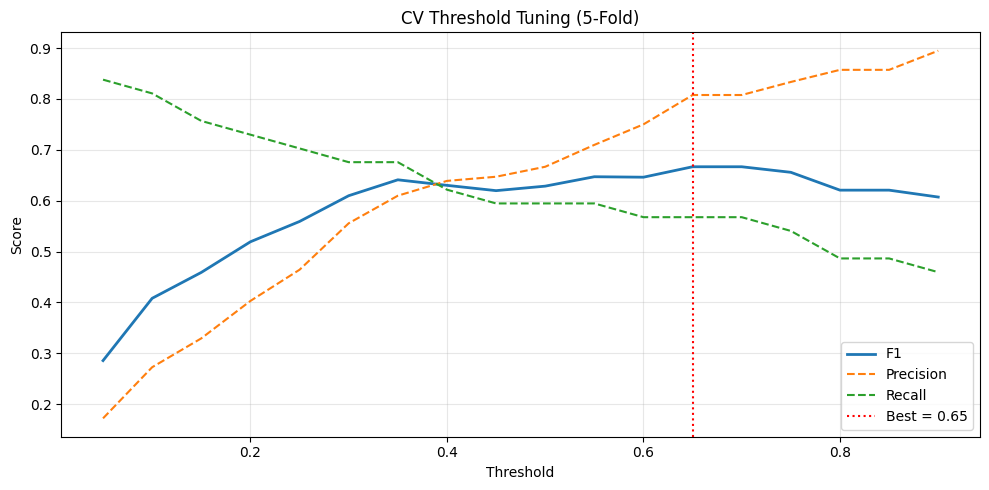

Best threshold: 0.65  |  F1: 0.6667  |  Precision: 0.8077  |  Recall: 0.5676


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost All Features — Test Set (threshold=0.65):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      0.80      0.89         5

    accuracy                           1.00       570
   macro avg       1.00      0.90      0.94       570
weighted avg       1.00      1.00      1.00       570

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9343 - loss: 0.1761 - val_accuracy: 1.0000 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9780 - loss: 0.0653 - val_accuracy: 1.0000 - val_loss: 3.5609e-04 - learning_rate: 0.0010
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9848 - loss: 0.0371 - val_accuracy: 1.0000 - val_loss: 2.7673e-04 - learning_rate: 0.0010
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9884 - loss: 0.0332 - val_accuracy: 1.0000 - val_loss: 1.7673e-04 - learning_rate: 0.0010
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9899 - loss: 0.0279 - val_accuracy: 1.0000 - val_loss: 5.6010e-05 - learning_rate: 0.0010
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9918 - loss: 0.0230 - val_accuracy: 1.0000 - val_loss: 1.3434e-05 - learning_rate: 0.0010
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9911 -

In [ ]:

print("Tuning threshold for XGBoost on all features...")
best_thresh_mega = cv_tune_threshold(X_train_mega, y_train, scale=True)
train_and_evaluate(X_train_mega, y_train, X_test_mega, y_test,
                   threshold=best_thresh_mega, scale=True, label='XGBoost All Features')


scaler_mega = StandardScaler()
X_train_mega_scaled = scaler_mega.fit_transform(X_train_mega)
X_test_mega_scaled = scaler_mega.transform(X_test_mega)

smote_mega = SMOTE(random_state=42)
X_train_mega_res, y_train_mega_res = smote_mega.fit_resample(X_train_mega_scaled, y_train)

X_train_mega_cnn = X_train_mega_res.reshape(X_train_mega_res.shape[0], -1, 1)
X_test_mega_cnn = X_test_mega_scaled.reshape(X_test_mega_scaled.shape[0], -1, 1)

cnn_mega = build_cnn(input_shape=(X_train_mega_cnn.shape[1], 1))
cnn_mega.fit(
    X_train_mega_cnn, y_train_mega_res,
    epochs=50, batch_size=32, validation_split=0.2,
    callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
    verbose=1
)

y_mega_probs = cnn_mega.predict(X_test_mega_cnn).flatten()
results_mega = []
for t in np.arange(0.05, 0.95, 0.05):
    y_pred = (y_mega_probs > t).astype(int)
    results_mega.append({'threshold': t, 'f1': f1_score(y_test, y_pred, zero_division=0)})

best_t_mega = pd.DataFrame(results_mega).loc[pd.DataFrame(results_mega)['f1'].idxmax(), 'threshold']
y_pred_mega = (y_mega_probs > best_t_mega).astype(int)

print(f"\nCNN All Features — Test Set (threshold={best_t_mega:.2f}):")
print(classification_report(y_test, y_pred_mega, zero_division=0))

# Data Augmentation

In [ ]:
# === Data Augmentation for Exoplanet Light Curves ===

def augment_signal(signal, n_augments=10):
    """
    Generate augmented versions of a single light curve.
    """
    augmented = []
    sig = np.array(signal, dtype=float)

    for _ in range(n_augments):
        aug = sig.copy()

        # 1. Add gaussian noise
        noise_level = np.std(aug) * np.random.uniform(0.01, 0.05)
        aug = aug + np.random.normal(0, noise_level, len(aug))

        # 2. Random phase shift (roll the signal)
        shift = np.random.randint(-200, 200)
        aug = np.roll(aug, shift)

        # 3. Slight vertical scale (simulates different dip depths)
        scale = np.random.uniform(0.95, 1.05)
        aug = (aug - np.mean(aug)) * scale + np.mean(aug)

        # 4. Slight time stretch/compress (resample)
        if np.random.random() > 0.5:
            stretch = np.random.uniform(0.97, 1.03)
            x_old = np.linspace(0, 1, len(aug))
            x_new = np.linspace(0, 1, int(len(aug) * stretch))
            aug_stretched = np.interp(x_new, x_old, aug)
            # Resize back to original length
            x_final = np.linspace(0, 1, len(aug))
            x_stretched = np.linspace(0, 1, len(aug_stretched))
            aug = np.interp(x_final, x_stretched, aug_stretched)

        # 5. Random flip (time reversal) — transit shape is roughly symmetric
        if np.random.random() > 0.5:
            aug = aug[::-1].copy()

        augmented.append(aug)

    return np.array(augmented)


# Only augment the POSITIVE samples
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

pos_mask = y_train_np == 1
X_pos = X_train_np[pos_mask]
X_neg = X_train_np[~pos_mask]

print(f"Original positives: {len(X_pos)}")
print(f"Original negatives: {len(X_neg)}")

# Generate augmented positives
n_augments_per_sample = 30  # 37 * 30 = ~1110 synthetic positives
augmented_positives = []
for i, sig in enumerate(X_pos):
    augmented_positives.append(augment_signal(sig, n_augments=n_augments_per_sample))

augmented_positives = np.vstack(augmented_positives)
print(f"Augmented positives: {augmented_positives.shape[0]}")

# Combine: original data + augmented positives
X_train_aug = np.vstack([X_train_np, augmented_positives])
y_train_aug = np.concatenate([y_train_np, np.ones(len(augmented_positives))])

print(f"\nAugmented dataset:")
print(f"  Total:     {len(X_train_aug)}")
print(f"  Positives: {int(y_train_aug.sum())}")
print(f"  Negatives: {int((y_train_aug == 0).sum())}")

Original positives: 37
Original negatives: 5050
Augmented positives: 1110

Augmented dataset:
  Total:     6197
  Positives: 1147
  Negatives: 5050


In [ ]:
# === Extract all features on augmented data ===
print("Extracting FFT features...")
X_train_aug_fft = apply_fft(X_train_aug)
# Test set stays the same — never augment test
X_test_fft_final = apply_fft(np.array(X_test))

print("Extracting summary stats...")
X_train_aug_stats = extract_summary_stats(X_train_aug)
X_test_stats_final = extract_summary_stats(np.array(X_test))

print("Extracting rolling window features...")
X_train_aug_rolling = rolling_window_features(X_train_aug)
X_test_rolling_final = rolling_window_features(np.array(X_test))

print("Extracting dip detection features...")
X_train_aug_dips = dip_detection_features(X_train_aug)
X_test_dips_final = dip_detection_features(np.array(X_test))

print("Extracting autocorrelation features...")
X_train_aug_autocorr = autocorrelation_features(X_train_aug)
X_test_autocorr_final = autocorrelation_features(np.array(X_test))

print("Extracting derivative features...")
X_train_aug_deriv = derivative_features(X_train_aug)
X_test_deriv_final = derivative_features(np.array(X_test))

# Combine
X_train_aug_all = np.hstack([
    X_train_aug_fft, X_train_aug_stats, X_train_aug_rolling,
    X_train_aug_dips, X_train_aug_autocorr, X_train_aug_deriv
])
X_test_all_final = np.hstack([
    X_test_fft_final, X_test_stats_final, X_test_rolling_final,
    X_test_dips_final, X_test_autocorr_final, X_test_deriv_final
])

print(f"\nAugmented feature shape: {X_train_aug_all.shape}")
print(f"Test feature shape:      {X_test_all_final.shape}")

Extracting FFT features...
Extracting summary stats...
Extracting rolling window features...
Extracting dip detection features...
Extracting autocorrelation features...
Extracting derivative features...

Augmented feature shape: (6197, 1659)
Test feature shape:      (570, 1659)


In [ ]:
# === CNN on Augmented Data (no SMOTE needed — augmentation handles balance) ===
scaler_aug = StandardScaler()
X_train_aug_scaled = scaler_aug.fit_transform(X_train_aug_all)
X_test_aug_scaled = scaler_aug.transform(X_test_all_final)

X_train_aug_cnn = X_train_aug_scaled.reshape(X_train_aug_scaled.shape[0], -1, 1)
X_test_aug_cnn = X_test_aug_scaled.reshape(X_test_aug_scaled.shape[0], -1, 1)

print(f"CNN input shape: {X_train_aug_cnn.shape}")

y_train_aug_series = pd.Series(y_train_aug)

cnn_aug = build_cnn(input_shape=(X_train_aug_cnn.shape[1], 1))
cnn_aug.fit(
    X_train_aug_cnn, y_train_aug,
    epochs=70, batch_size=16, validation_split=0.0,
    callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
    verbose=1
)

y_aug_probs = cnn_aug.predict(X_test_aug_cnn).flatten()

results_aug = []
for t in np.arange(0.05, 0.95, 0.05):
    y_pred = (y_aug_probs > t).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    results_aug.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec})

results_aug_df = pd.DataFrame(results_aug)
best_aug = results_aug_df.loc[results_aug_df['f1'].idxmax()]

y_pred_aug = (y_aug_probs > best_aug['threshold']).astype(int)

print(f"\nCNN Augmented — Test Set (threshold={best_aug['threshold']:.2f}):")
print(classification_report(y_test, y_pred_aug, zero_division=0))

print(f"\nCNN probs for exoplanets: {y_aug_probs[y_test == 1]}")

CNN input shape: (6197, 1659, 1)
Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9033 - loss: 0.2401 - learning_rate: 0.0010
Epoch 2/70
 18/388 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9333 - loss: 0.1502

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9618 - loss: 0.0955 - learning_rate: 0.0010
Epoch 3/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9729 - loss: 0.0711 - learning_rate: 0.0010
Epoch 4/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9772 - loss: 0.0557 - learning_rate: 0.0010
Epoch 5/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9848 - loss: 0.0407 - learning_rate: 0.0010
Epoch 6/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9877 - loss: 0.0327 - learning_rate: 0.0010
Epoch 7/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9868 - loss: 0.0319 - learning_rate: 0.0010
Epoch 8/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9834 - loss: 0.0405 - learning_rate: 0.0010
Epoch 9/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9868 - loss: 0.0318 - learning_rate: 0.0010
Epoch 10/70
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9906 - loss: 0.0239 - learning_rate: 0.0010
Epoch 11/70
388/388 

CV threshold tuning for CNN (this will take a few minutes)...
  Fold 1/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 3/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 4/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 5/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


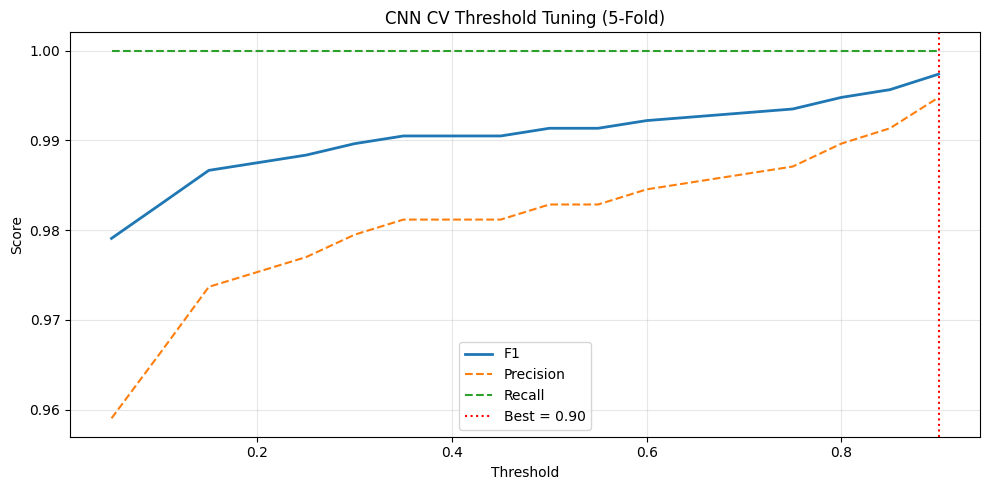

Best threshold: 0.90  |  F1: 0.9974  |  Precision: 0.9948  |  Recall: 1.0000


In [ ]:
# === CV Threshold Tuning for CNN ===

def cv_tune_threshold_cnn(X, y, n_splits=5, thresholds=np.arange(0.05, 0.95, 0.05)):
    """
    Stratified k-fold CV for CNN threshold tuning.
    Trains a CNN per fold, collects out-of-fold predictions,
    then sweeps thresholds on all OOF predictions.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold+1}/{n_splits}...")
        X_tr, X_vl = X[train_idx], X[val_idx]
        y_tr, y_vl = y[train_idx], y[val_idx]

        # Scale
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_vl = sc.transform(X_vl)

        # SMOTE
        sm = SMOTE(random_state=42)
        X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

        # Shuffle
        shuf = np.random.permutation(len(y_tr_res))
        X_tr_res = X_tr_res[shuf]
        y_tr_res = y_tr_res[shuf]

        # Reshape for CNN
        X_tr_cnn = X_tr_res.reshape(X_tr_res.shape[0], -1, 1)
        X_vl_cnn = X_vl.reshape(X_vl.shape[0], -1, 1)

        # Build and train
        model = build_cnn(input_shape=(X_tr_cnn.shape[1], 1))
        model.fit(
            X_tr_cnn, y_tr_res,
            epochs=50, batch_size=32, validation_split=0.1,
            callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
            verbose=0
        )

        oof_probs[val_idx] = model.predict(X_vl_cnn, verbose=0).flatten()

    # Sweep thresholds on OOF predictions
    results = []
    for t in thresholds:
        y_pred = (oof_probs > t).astype(int)
        f1 = f1_score(y, y_pred, zero_division=0)
        prec = precision_score(y, y_pred, zero_division=0)
        rec = recall_score(y, y_pred, zero_division=0)
        results.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec})

    results_df = pd.DataFrame(results)
    best_idx = results_df['f1'].idxmax()
    best = results_df.loc[best_idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(results_df['threshold'], results_df['f1'], label='F1', linewidth=2)
    ax.plot(results_df['threshold'], results_df['precision'], label='Precision', linestyle='--')
    ax.plot(results_df['threshold'], results_df['recall'], label='Recall', linestyle='--')
    ax.axvline(best['threshold'], color='red', linestyle=':', label=f'Best = {best["threshold"]:.2f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'CNN CV Threshold Tuning ({n_splits}-Fold)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"Best threshold: {best['threshold']:.2f}  |  F1: {best['f1']:.4f}  |  Precision: {best['precision']:.4f}  |  Recall: {best['recall']:.4f}")
    return best['threshold']


# Run CV threshold tuning on your all-features data
print("CV threshold tuning for CNN (this will take a few minutes)...")
best_thresh_cnn_cv = cv_tune_threshold_cnn(X_train_aug_all, y_train_aug)

In [ ]:
# Train final CNN on ALL augmented training data
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_aug_all)
X_test_final_scaled = scaler_final.transform(X_test_all_final)

smote_final = SMOTE(random_state=42)
X_train_final_res, y_train_final_res = smote_final.fit_resample(X_train_final_scaled, y_train_aug)

shuf = np.random.permutation(len(y_train_final_res))
X_train_final_res = X_train_final_res[shuf]
y_train_final_res = y_train_final_res[shuf]

X_train_final_cnn = X_train_final_res.reshape(X_train_final_res.shape[0], -1, 1)
X_test_final_cnn = X_test_final_scaled.reshape(X_test_final_scaled.shape[0], -1, 1)

cnn_final = build_cnn(input_shape=(X_train_final_cnn.shape[1], 1))
cnn_final.fit(
    X_train_final_cnn, y_train_final_res,
    epochs=25, batch_size=16, validation_split=0.20,
    callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
    verbose=1
)


y_final_probs = cnn_final.predict(X_test_final_cnn).flatten()
y_pred_final = (y_final_probs > best_thresh_cnn_cv).astype(int)

print(f"\nCNN Final — Test Set (CV threshold={best_thresh_cnn_cv:.2f}):")
print(classification_report(y_test, y_pred_final, zero_division=0))
print(f"CNN probs for exoplanets: {y_final_probs[y_test == 1]}")

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


505/505 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9048 - loss: 0.2532 - val_accuracy: 0.9347 - val_loss: 0.1948 - learning_rate: 0.0010
Epoch 2/25
505/505 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9712 - loss: 0.0849 - val_accuracy: 0.9743 - val_loss: 0.0831 - learning_rate: 0.0010
Epoch 3/25
505/505 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9793 - loss: 0.0601 - val_accuracy: 0.9861 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 4/25
505/505 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9856 - loss: 0.0437 - val_accuracy: 0.9906 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 5/25
505/505 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9854 - loss: 0.0393 - val_accuracy: 0.9896 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 6/25
505/505 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9882 - loss: 0.0361 - val_accuracy: 0.9916 - val_loss: 0.0246 - learning_rate: 0.0010
Epoch 7/25
505/505 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9916 - loss: 0.0278 - val_accur

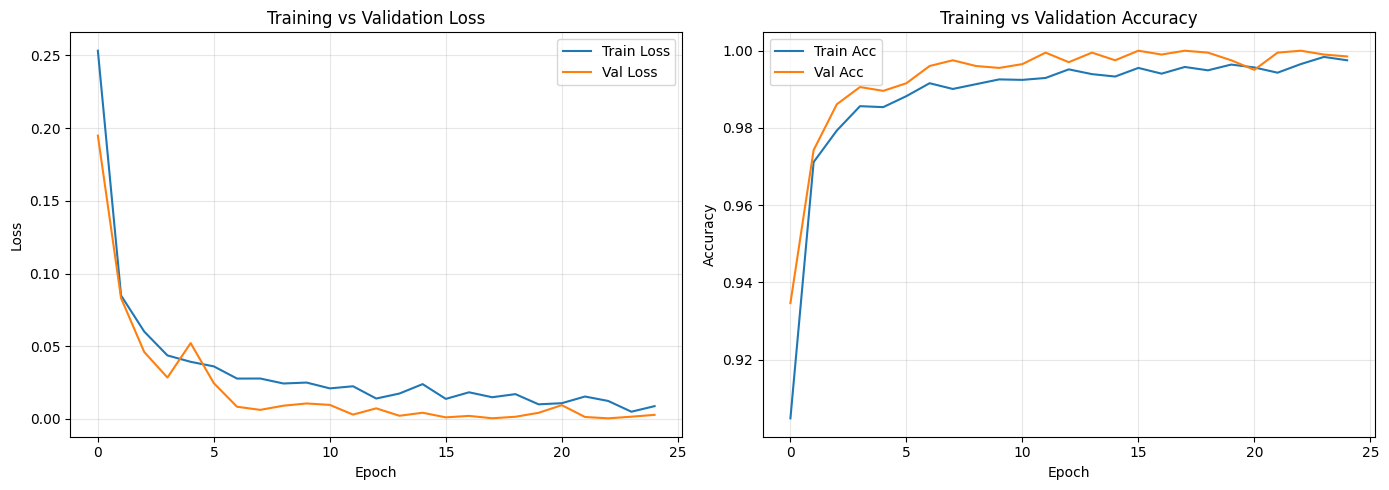

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(cnn_final.history.history['loss'], label='Train Loss')
axes[0].plot(cnn_final.history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(cnn_final.history.history['accuracy'], label='Train Acc')
axes[1].plot(cnn_final.history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()